In [1]:
# Import necessary libraries
import itertools
import numpy as np
import pandas as pd 
from numpy import std
from numpy import mean
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
%matplotlib inline


In [2]:
# Read the dataset
df = pd.read_csv("airquality.csv",index_col=0)

# Take a quick look at the data
df.head(10)


,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5
6,28.0,NaN,14.9,66,5,6
7,23.0,299.0,8.6,65,5,7
8,19.0,99.0,13.8,59,5,8
9,8.0,19.0,20.1,61,5,9
10,NaN,194.0,8.6,69,5,10


In [3]:
# Use the column Ozone to drop any NaNs from the dataframe
df = df[df.Ozone.notna()]


In [4]:
# Assign the values of Ozon column as the predictor variable
x = df[['Ozone']].values

# Use temperature as the response data
y = df['Temp']


In [5]:
# Split the data into train and test sets with train size as 0.8 
# and set random_state as 102
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=102)


### Bagging Regressor

In [7]:
# Specify the number of bootstraps as 30
num_bootstraps = 30

# Specify the maximum depth of the decision tree as 3
max_depth = 3

# Define the Bagging Regressor Model
# Use Decision Tree as your base estimator with depth as mentioned in max_depth
# Initialise number of estimators using the num_bootstraps value
model = BaggingRegressor(
    DecisionTreeRegressor(max_depth = max_depth),
    n_estimators= num_bootstraps
)
                        

# Fit the model on the train data
model.fit(x_train, y_train)


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...r(max_depth=3)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",30
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


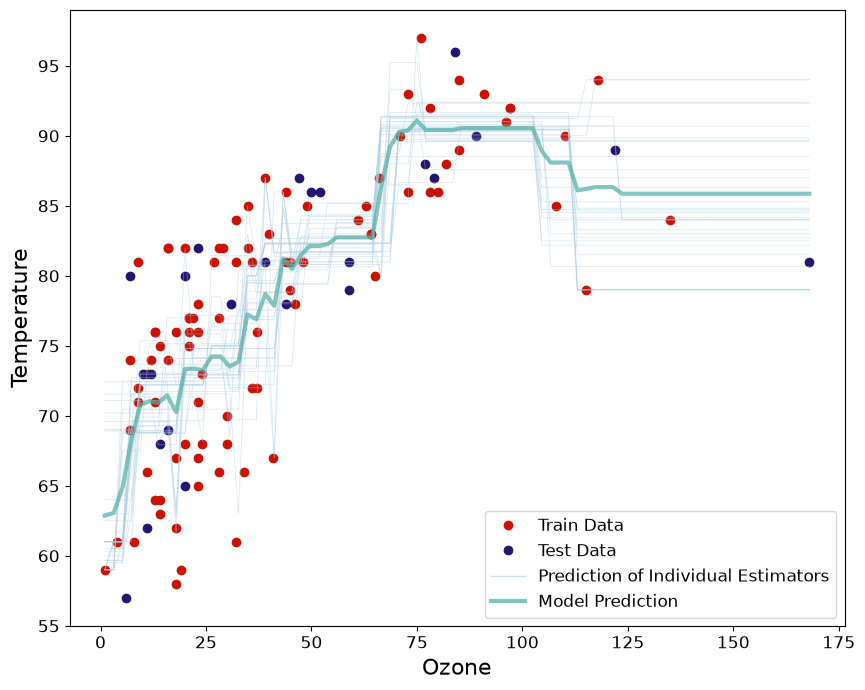

In [9]:
# Helper code to plot the predictions of individual estimators 
plt.figure(figsize=(10,8))

xrange = np.linspace(x.min(),x.max(),80).reshape(-1,1)
plt.plot(x_train,y_train,'o',color='#CC1100', markersize=6, label="Train Data")
plt.plot(x_test,y_test,'o',color='#241571', markersize=6, label="Test Data")
plt.xlim()
for i in model.estimators_:
    y_pred1 = i.predict(xrange)
    plt.plot(xrange,y_pred1,alpha=0.5,linewidth=0.5,color = '#ABCCE3')
plt.plot(xrange,y_pred1,alpha=0.6,linewidth=1,color = '#ABCCE3',label="Prediction of Individual Estimators")


y_pred = model.predict(xrange)
plt.plot(xrange,y_pred,alpha=0.7,linewidth=3,color='#50AEA4', label='Model Prediction')
plt.xlabel("Ozone", fontsize=16)
plt.ylabel("Temperature", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='best',fontsize=12)
plt.show();


In [11]:
# Compute the test MSE of the prediction of first estimator
y_pred1 = model.estimators_[0].predict(x_test)

# Print the test MSE 
print("The test MSE of one estimator in the model is", round(mean_squared_error(y_test,y_pred1),2))


The test MSE of one estimator in the model is 42.63


In [12]:
### edTest(test_mse) ###
# Compute the test MSE of the model prediction
y_pred = model.predict(x_test)

# Print the test MSE 
print("The test MSE of the model is",round(mean_squared_error(y_test,y_pred),2))


The test MSE of the model is 31.49
